---
title: "Chapter 9: Classification Metrics"
---

::: {.callout-lo}
By the end of this chapter, you will be able to:

- Explain why high accuracy can hide an ineffective classifier.
- Interpret confusion matrices, precision, recall, F1, and classification reports.
- Explain how a decision threshold changes predictions and error counts.
- Interpret PR and ROC curves and distinguish their summaries from metrics at one threshold.
- Choose evaluation criteria that reflect an application's needs.
- Use multiple metrics in cross-validation and select a pipeline and threshold without using the test set.
- Compare performance across groups and explain the limits of such comparisons.
:::

In Chapter 8, we searched for the pipeline with the highest cross-validation accuracy. But does the highest accuracy always identify the most useful model? Imagine you are building a system for a bank that flags suspicious credit-card transactions for investigation. In a hypothetical batch of 10,000 transactions, 20 are fraudulent. Your model correctly classifies 9,980 transactions (an accuracy of 99.8%) but catches none of the fraud. How could a model get almost every prediction right and still fail at its job?

Missing fraud can let unauthorized charges go unnoticed. Flagging legitimate purchases can inconvenience customers and consume investigation time. Both kinds of mistake matter, but their consequences are different. How can we compare models when different mistakes have different consequences?

In [1]:
#| code-fold: true
#| code-summary: "Show imports and setup"

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import make_column_transformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay,
    accuracy_score, average_precision_score, classification_report,
    confusion_matrix, f1_score, precision_recall_curve, precision_score,
    recall_score, roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

DATA_DIR = Path("data")
CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

## Fraud detection: when accuracy is not enough

Let’s turn the bank scenario into a prediction task using the [Credit Card Fraud Detection dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud). Each row describes a credit-card transaction, and our task is to predict whether it is fraudulent. The target column, `Class`, records `1` for fraud and `0` for non-fraud. A prediction of `1` would flag a transaction for investigation; it would not by itself establish that fraud occurred.

We have numeric features describing each transaction, including its amount and a set of anonymized features named `V1`, `V2`, and so on. We do not need to interpret those anonymized features to investigate how well our predictions work.

::: {.callout-note collapse="true" title="Loading the data"}
The CSV is about 150 MB. The code uses `data/creditcard.csv` if you have a local copy; otherwise it reads the remote copy used in the lecture notes. Keep large downloaded data files out of version control.
:::

In [2]:
fraud_path = DATA_DIR / "creditcard.csv"
DATA_URL = "https://github.com/firasm/bits/raw/refs/heads/master/creditcard.csv"
fraud_df = pd.read_csv(fraud_path if fraud_path.exists() else DATA_URL)

As in earlier chapters, we reserve the test set before exploring the data or comparing models. We also set aside a validation set so that we can examine predictions from a fitted model on examples it has not seen. Later, we will use cross-validation within the training set to compare candidate pipelines, and the validation set to choose a decision threshold. The test set stays untouched until the final evaluation.

We use `stratify` to approximately preserve the fraction of fraud cases in each split. This does not make the classes equally common; it helps avoid a split with very few fraud examples. Stratification is not the default in `train_test_split`.

In [3]:
fraud_development, fraud_test = train_test_split(
    fraud_df, test_size=0.3, random_state=111, stratify=fraud_df["Class"]
)
fraud_fit, fraud_valid = train_test_split(
    fraud_development, test_size=0.3, random_state=123,
    stratify=fraud_development["Class"],
)
X_fit = fraud_fit.drop(columns=["Class", "Time"])
y_fit = fraud_fit["Class"]
X_valid = fraud_valid.drop(columns=["Class", "Time"])
y_valid = fraud_valid["Class"]
X_test = fraud_test.drop(columns=["Class", "Time"])
y_test = fraud_test["Class"]

# Show a few columns from the training set to see the structure of the data.
fraud_fit[["Amount", "V1", "V2", "V3", "Class"]].head()

,Amount,V1,V2,V3,Class
161019,33.35,1.995966,-0.247681,-1.774412,0
179531,10.00,2.049079,-0.189257,-1.264731,0
229408,18.63,2.030060,0.454393,-2.473850,0
44337,1.98,-1.724699,2.120453,0.049281,0
143423,150.00,-1.361361,-0.955378,1.997082,0


We omit `Time` and use random splits to keep the focus on evaluation metrics. A system intended to predict future transactions would need an evaluation that accounts for time and, where relevant, repeated customers. A random split is not automatically a realistic deployment evaluation.

How often does fraud occur in our training set? Let’s look at both counts and percentages.

In [4]:
class_counts = y_fit.value_counts().reindex([0, 1])
class_summary = pd.DataFrame({
    "Transactions": class_counts,
    "Percentage": 100 * class_counts / len(y_fit),
})
class_summary.index = pd.Index(["Non-fraud", "Fraud"], name="Actual class")
class_summary.round({"Percentage": 3})

,Transactions,Percentage
Actual class,,
Non-fraud,139313,99.827
Fraud,241,0.173


Only about 0.17% of these transactions are fraud: fewer than 2 in every 1,000. This is an example of **class imbalance**, where one class occurs much more often than another. Here, rarity is part of the problem we want to solve. A useful detector must find fraud among many legitimate transactions.

Class imbalance raises two different questions: how should we evaluate a model, and should we change how it learns or makes predictions? We will start with evaluation: choosing measures that reveal whether the model does what we need. Later, we will explore changing the decision threshold or giving fraud examples more weight during training, and use those measures to judge whether the changes help.

::: {.callout-reflection}
Suppose we predict “non-fraud” for every transaction. Using the class percentages above, what accuracy would you expect on data with similar proportions? How many fraud cases would this rule catch?
:::

We can implement this rule with the familiar `DummyClassifier`. With `strategy="most_frequent"`, it learns which class is most common in the training set and predicts that class for every example, regardless of its features.

In [5]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_fit, y_fit)
dummy_predictions = dummy.predict(X_valid)
print(f"Dummy validation accuracy: {accuracy_score(y_valid, dummy_predictions):.3%}")

Dummy validation accuracy: 99.828%


An accuracy of about 99.8% resolves the opening puzzle. The classifier gets the legitimate transactions right and misses every fraud case. In the hypothetical batch from the introduction, this same rule would make 9,980 correct predictions out of 10,000 without catching any of the 20 fraudulent transactions. High accuracy alone does not establish that we have a useful fraud detector.

Can a model that learns from the transaction features do better? Let’s try logistic regression from Chapter 7, with scaling inside a pipeline. We fit on the same data and evaluate on the same validation examples so the comparison is meaningful.

In [6]:
pipe_lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
pipe_lr.fit(X_fit, y_fit)
models = {"Always non-fraud": dummy, "Logistic regression": pipe_lr}

pd.Series(
    {name: accuracy_score(y_valid, model.predict(X_valid)) for name, model in models.items()},
    name="Validation accuracy",
).to_frame().round(6)

,Validation accuracy
Always non-fraud,0.998278
Logistic regression,0.999264


Both accuracies are close to 1. The difference looks small, but accuracy alone does not tell us what changed for the fraud cases. To see that, let’s count how many fraudulent transactions each model catches and how many legitimate transactions it flags by mistake. We can do this directly by comparing the predictions with the known validation labels.

In [7]:
comparison = {}
for name, model in models.items():
    predictions = model.predict(X_valid)
    comparison[name] = {
        "Fraud caught": int(((y_valid == 1) & (predictions == 1)).sum()),
        "Fraud missed": int(((y_valid == 1) & (predictions == 0)).sum()),
        "Legitimate transactions flagged": int(((y_valid == 0) & (predictions == 1)).sum()),
    }
pd.DataFrame(comparison).T

,Fraud caught,Fraud missed,Legitimate transactions flagged
Always non-fraud,0,103,0
Logistic regression,71,32,12


Of the 103 fraud cases in this validation set, logistic regression catches 71 and misses 32. In total, it flags 83 transactions for investigation: 71 are actually fraudulent, while the other 12 are legitimate transactions incorrectly flagged as fraud. These 12 false alarms are called **false positives**. The dummy classifier catches no fraud at all. The small difference in accuracy hides a substantial difference in what these models do.

Logistic regression is more useful for finding fraud in this comparison, but is it good enough for the bank? That depends on whether catching 71 cases justifies the investigations it triggers, and whether missing 32 cases is acceptable. We need a clearer way to describe these different outcomes before choosing a model. A **confusion matrix** will organize the counts, and the metrics derived from it will help us compare the kinds of mistakes that matter.

## Understanding mistakes: confusion matrices, precision, recall, and F1

Our logistic-regression model flagged 83 transactions: 71 were fraud and 12 were legitimate. It also missed 32 fraud cases. These counts describe different aspects of its behaviour. Let’s organize them so that we can ask more precise questions about how well the detector works.

### Organizing mistakes: the confusion matrix

We call fraud the **positive class** because it is the event we want to detect; non-fraud is the **negative class**. “Positive” does not mean desirable. We must specify which class is positive before interpreting the metrics that follow.

A **confusion matrix** groups predictions by their actual and predicted classes. For our logistic-regression model, the validation counts are:

| Actual class | Predicted non-fraud | Predicted fraud |
|---|---|---|
| Non-fraud | **59,695 true negatives (TN):** legitimate transactions correctly left unflagged | **12 false positives (FP):** legitimate transactions incorrectly flagged |
| Fraud | **32 false negatives (FN):** fraud cases missed | **71 true positives (TP):** fraud cases caught |

“True” and “false” describe whether the prediction was correct; “positive” and “negative” describe what was predicted. For example, a false negative is an actual fraud case that the model predicted as non-fraud. The two diagonal entries count correct predictions; the other two count mistakes.

Scikit-learn can display these counts directly. We specify the class order with `labels=[0, 1]` and supply readable names with `display_labels`. Rows show actual classes and columns show predicted classes. Always check the axes and class order when reading a confusion matrix.

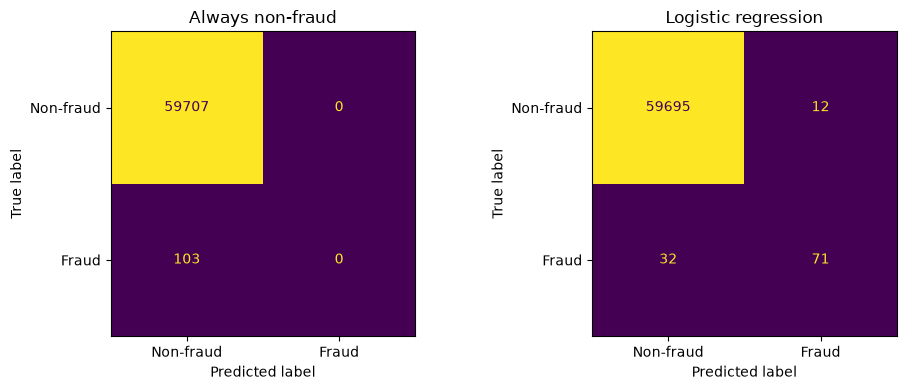

In [8]:
#| label: fig-fraud-confusion
#| fig-cap: "Validation confusion matrices distinguish false alarms from missed fraud."
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model, X_valid, y_valid, labels=[0, 1],
        display_labels=["Non-fraud", "Fraud"], values_format="d", ax=ax,
        colorbar=False,
    )
    ax.set_title(name)
fig.tight_layout()
plt.show()

The dummy classifier’s predicted-fraud column is empty: it never flags a transaction, so all 103 fraud cases appear as false negatives. Logistic regression moves 71 of those cases into the true-positive cell, but also produces 12 false positives. The matrices make this difference visible even though both classifiers have high accuracy.

The counts are useful, but the bank also needs to know what they mean relative to its workload and the fraud it hopes to catch. How reliable are the alerts? How much of the fraud is being missed? These questions require different denominators.

### Asking different questions: precision, recall, and F1

Imagine reviewing the 83 transactions flagged by logistic regression. Of these, 71 are actually fraudulent. **Precision** asks: *Of all the transactions predicted as fraud, what fraction really were fraud?*

$$
\text{precision}=\frac{\text{fraud cases caught}}{\text{all transactions flagged}}
=\frac{TP}{TP+FP}=\frac{71}{71+12}\approx0.855.
$$

About 86% of the alerts correspond to fraud. The remaining 14% are false alarms. Precision tells us about the reliability of the alerts, but not how many fraud cases were left unflagged.

Now imagine starting with the 103 actual fraud cases instead. The model caught 71 and missed 32. **Recall** asks: *Of all the actual fraud cases, what fraction did we catch?*

$$
\text{recall}=\frac{\text{fraud cases caught}}{\text{all actual fraud cases}}
=\frac{TP}{TP+FN}=\frac{71}{71+32}\approx0.689.
$$

The detector catches about 69% of the fraud cases. The other 31% go undetected. Recall tells us about coverage of the fraud, but not how many legitimate transactions were flagged along the way.

Both metrics count the same 71 true positives in the numerator. The difference is the group we compare them with:

| Metric | Start with this group | Count the fraud cases caught within it |
|---|---|---|
| Precision | 83 predicted positives: 71 TP + 12 FP | 71 out of 83 |
| Recall | 103 actual positives: 71 TP + 32 FN | 71 out of 103 |

High precision means a small **fraction of alerts** are false alarms, not necessarily a small number of false alarms. High recall means a small **fraction of actual positives** are missed. Neither metric alone answers both questions.

:::: {.callout-reflection}
Suppose a detector flags every transaction in this validation set. What would its precision and recall be? Would perfect recall make it useful for a team that has to investigate each alert?

::: {.callout-tip collapse="true" title="Discussion"}
It catches all 103 fraud cases, so recall is 1. But all 59,810 transactions are flagged, giving precision $103/59{,}810\approx0.00172$, or about 0.17%. Almost every investigation would concern a legitimate transaction. Perfect recall alone does not establish that the detector is useful.
:::
::::

What if we want a single score that rewards both reliable alerts and catching fraud? The **F1-score** combines precision and recall using their **harmonic mean**:

$$
F_1=2\frac{\text{precision}\times\text{recall}}{\text{precision}+\text{recall}}
=\frac{2TP}{2TP+FP+FN}.
$$

The harmonic mean gives a lower score than the ordinary arithmetic mean when its two inputs differ. A very high precision therefore cannot fully compensate for a very low recall, or vice versa. A high F1 requires both to be high.

For our logistic-regression model,

$$
F_1=\frac{2\times71}{2\times71+12+32}=\frac{142}{186}\approx0.763.
$$

Unlike accuracy, F1 does not include true negatives. Adding more correctly classified legitimate transactions would increase accuracy but leave F1 unchanged. That can be helpful when we care about finding fraud among many legitimate transactions. However, F1 does not encode the bank’s financial costs or investigation capacity. It is one possible summary, not a universal definition of a good detector.

We can calculate these metrics with scikit-learn’s `precision_score`, `recall_score`, and `f1_score`. For these binary labels, their default positive class is `1`, which matches our fraud class. The helper below collects the counts and scores so that we can reuse them when comparing predictions later. With `labels=[0, 1]`, flattening the confusion matrix using `.ravel()` returns TN, FP, FN, and TP in that order.

The dummy classifier needs one special consideration: because it predicts no positives, its precision has denominator zero and is undefined. We use `zero_division=0` to report zero in that case. This is a reporting convention, not a measured proportion. Recall is similarly undefined if an evaluation set contains no actual positives. Our validation set does contain positives, so the dummy classifier’s recall and F1 are both zero.

In [9]:
def prediction_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }

pd.DataFrame({
    name: prediction_metrics(y_valid, model.predict(X_valid))
    for name, model in models.items()
}).T

,TN,FP,FN,TP,accuracy,precision,recall,F1
Always non-fraud,59707.0,0.0,103.0,0.0,0.998278,0.000000,0.00000,0.000000
Logistic regression,59695.0,12.0,32.0,71.0,0.999264,0.855422,0.68932,0.763441


### Reading a classification report

The table above reproduces our calculations: logistic regression has precision about 0.855, recall about 0.689, and F1 about 0.763 for fraud. Scikit-learn’s `classification_report` provides a convenient summary of these metrics **for each class**, together with **support**, the number of actual examples of that class.

Let’s read the fraud row first, since it answers the questions we have been asking.

In [10]:
print(classification_report(
    y_valid, pipe_lr.predict(X_valid), labels=[0, 1],
    target_names=["Non-fraud", "Fraud"], digits=3, zero_division=0,
))

              precision    recall  f1-score   support

   Non-fraud      0.999     1.000     1.000     59707
       Fraud      0.855     0.689     0.763       103

    accuracy                          0.999     59810
   macro avg      0.927     0.845     0.882     59810
weighted avg      0.999     0.999     0.999     59810



The **Fraud** row matches our calculations. Its support is 103: there are 103 actual fraud cases, regardless of how the model classifies them. Support is not the number of transactions flagged, which was 83.

The **Non-fraud** row treats non-fraud as the class of interest. Its precision asks, “Of the transactions predicted as non-fraud, what fraction really were non-fraud?” Its recall asks, “Of the actual non-fraud transactions, what fraction were correctly left unflagged?” These values are close to 1 because the few mistakes are small relative to the many legitimate transactions. They do not mean that nearly all fraud was caught.

The report also provides two ways to average the class-specific scores. The **macro average** gives each class equal weight. For example, macro recall is the average of non-fraud recall and fraud recall, so the rare fraud class contributes just as much as the common non-fraud class.

The **weighted average** weights each class by its support. Here, 59,707 non-fraud examples vastly outnumber the 103 fraud examples, so the weighted averages are dominated by non-fraud performance. A weighted F1 close to 1 can therefore coexist with missing 32 of the 103 fraud cases. For this task, we should keep the fraud row visible rather than relying on the overall averages.

Each reported F1 average averages the **class-specific F1 values**; it is not calculated by substituting averaged precision and recall into the F1 formula. The same report extends to multiclass problems by evaluating each class against all the other classes.

We now have a more informative description than accuracy alone: most of the model’s alerts are correct, but it misses nearly a third of the fraud. Can we catch more of those missed cases **without fitting a different model**? The next section explores that question by changing the decision threshold.

## Catching more fraud without retraining the model

Our fitted logistic-regression model misses 32 fraud cases at its default decision threshold. Before trying a different model, we can ask whether changing how we turn its probabilities into decisions would catch more of them. We will first explore thresholds on this one fitted model, then use PR and ROC curves to examine the choices they offer. Finally, we will consider which evaluation measures match the bank’s goals.

### Changing the decision threshold

In Chapter 7, logistic regression produced probabilities before converting them into labels. A **decision threshold** specifies how large the estimated fraud probability must be before we flag a transaction. We will explicitly use the rule “predict fraud when the probability is at least the threshold.” This also makes our treatment of ties clear.

The illustration below arranges transactions by their fraud scores; for our logistic-regression model, these are estimated fraud probabilities. Transactions at or to the right of the chosen threshold are predicted as fraud, and those to its left as non-fraud. The symbols show the actual classes, so we can see which predictions are mistakes.

![Moving the threshold changes which transactions are flagged without changing their scores. The precision arrows show a common tendency, not a guarantee.](img/fraud-thresholding.png){#fig-fraud-thresholding fig-alt="Fraudulent and legitimate transactions arranged along an increasing fraud-score axis, with low, medium, and high decision thresholds. Transactions to the right of a chosen threshold are flagged as fraud." width="100%"}

Moving the threshold to the **left** flags more transactions. We may catch more fraud, so recall increases or stays the same, but we may also add false alarms. Precision tends to fall. Moving the threshold to the **right** flags fewer transactions: recall decreases or stays the same, while precision tends to rise. Unlike recall, precision can move in either direction because it depends on the mix of fraudulent and legitimate transactions added or removed.

Throughout this process, the fitted model and its scores stay unchanged. Each threshold gives us a precision–recall pair; plotting those pairs across thresholds will give us the **precision–recall curve**. First, let’s inspect a few thresholds directly.

::: {.callout-reflection}
Before running the next cell, predict how missed fraud and false alarms will change as the threshold moves from 0.5 to 0.1. Can you guarantee which threshold has the highest F1?
:::

In [11]:
fraud_column = list(pipe_lr.classes_).index(1)
valid_probability = pipe_lr.predict_proba(X_valid)[:, fraud_column]
threshold_examples = [0.9, 0.5, 0.1, 0.01]
threshold_table = pd.DataFrame([
    {"threshold": threshold, **prediction_metrics(y_valid, valid_probability >= threshold)}
    for threshold in threshold_examples
]).set_index("threshold")
threshold_table

,TN,FP,FN,TP,accuracy,precision,recall,F1
threshold,,,,,,,,
0.90,59697,10,47,56,0.999047,0.848485,0.543689,0.662722
0.50,59695,12,32,71,0.999264,0.855422,0.689320,0.763441
0.10,59681,26,21,82,0.999214,0.759259,0.796117,0.777251
0.01,59594,113,15,88,0.997860,0.437811,0.854369,0.578947


An **operating point** is the combination of error rates or metrics obtained at a chosen threshold. The appropriate point depends on what happens after a flag: a low-cost manual review and an automatic transaction block can justify different choices.

For illustration, suppose our requirement is to catch at least 80% of fraud cases while keeping the proportion of false alerts as small as possible. Later we will choose the threshold with the highest validation precision among those reaching 80% validation recall. This is a development target, not a guarantee about future transactions. We must not choose the threshold by inspecting test results.

### Precision–recall curves

Instead of inspecting a few thresholds, a **precision–recall (PR) curve** shows precision against recall as the threshold varies. Recall is on the horizontal axis and precision on the vertical axis. The desirable region is the top right: many fraud cases caught with few false alerts relative to all alerts.

Lower thresholds move us towards larger recall, although precision can move up or down. Marking thresholds on the curve connects its shape to decisions we could actually make.

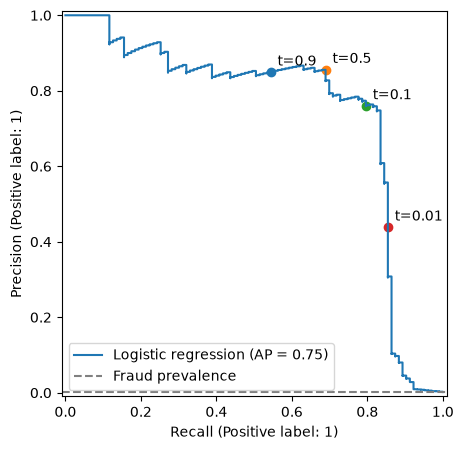

In [12]:
#| label: fig-fraud-pr
#| fig-cap: "The same logistic-regression scores give different operating points as the threshold changes."
fig, ax = plt.subplots(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(y_valid, valid_probability, ax=ax, name="Logistic regression")
for threshold, row in threshold_table.iterrows():
    ax.scatter(row["recall"], row["precision"])
    ax.annotate(f"t={threshold:g}", (row["recall"], row["precision"]), xytext=(5, 5), textcoords="offset points")
ax.axhline(y_valid.mean(), color="grey", linestyle="--", label="Fraud prevalence")
ax.legend()
plt.show()

The fraction of examples that are positive is called **prevalence**. Predicting every transaction as fraud gives recall 1 and precision equal to fraud prevalence. This prevalence also provides a useful reference level for an uninformative ranking, although finite-sample curves fluctuate.

**Average precision (AP)** summarizes precision as recall increases, weighting each precision by the increase in recall. It rewards retrieving positives early in the ranking. Scikit-learn's [AP calculation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html) is not the trapezoidal area obtained by connecting PR points with straight lines. We will use `average_precision_score` rather than interchange these calculations.

F1 evaluates class predictions at one threshold; AP summarizes a ranking across thresholds. AP accepts decision scores as well as probabilities. A high AP does not establish that a predicted probability of 0.8 corresponds to an 80% event frequency.

In [13]:
average_precision_score(y_valid, valid_probability)

0.747350326308888

### ROC curves

The PR curve tells us how reliable our alerts are at different levels of recall. Another question is how much disruption those alerts cause among legitimate transactions. To answer it, we measure false alarms relative to all actual negatives rather than relative to all alerts.

Recall is also called the **true positive rate (TPR)**. A **receiver operating characteristic (ROC) curve** plots it against the **false positive rate (FPR)**:

$$
\text{TPR}=\frac{TP}{TP+FN}, \qquad
\text{FPR}=\frac{FP}{FP+TN}.
$$

FPR asks what fraction of actual negatives were flagged. It is not $1-\text{precision}$, which asks what fraction of positive predictions were false alarms.

At a threshold above all scores, no examples are flagged, giving the bottom-left point. At a threshold below all scores, everything is flagged, giving the top-right point. The desirable region is the top left: high recall and low FPR.

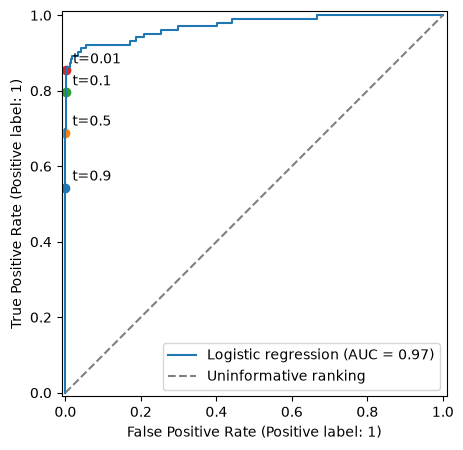

In [14]:
#| label: fig-fraud-roc
#| fig-cap: "A ROC curve measures false alarms relative to the actual negative class."
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_valid, valid_probability, ax=ax, name="Logistic regression")
for threshold, row in threshold_table.iterrows():
    fpr = row["FP"] / (row["FP"] + row["TN"])
    ax.scatter(fpr, row["recall"])
    ax.annotate(f"t={threshold:g}", (fpr, row["recall"]), xytext=(5, 5), textcoords="offset points")
ax.plot([0, 1], [0, 1], "--", color="grey", label="Uninformative ranking")
ax.legend()
plt.show()

**ROC AUC** is the area under the ROC curve. It has a useful interpretation: draw one positive and one negative at random; AUC measures how often the positive receives the higher score, giving half credit for ties. A perfect ordering has AUC 1; an uninformative ranking has expected AUC 0.5. Scores below 0.5 are possible.

Like AP, ROC AUC evaluates ranking rather than a particular threshold or the accuracy of probability estimates. Two models can have similar AUC yet behave differently in the region where we intend to operate.

In [15]:
roc_auc_score(y_valid, valid_probability)

0.9726235934346708

### Choosing evaluation metrics

Start with the action that follows a prediction. Who is affected by a missed positive? What happens after a false alarm? A metric makes some aspects of these consequences visible, but choosing it still requires context.

| Evaluation question | Useful measure or criterion | What else to inspect |
|---|---|---|
| What fraction of all decisions are correct? | Accuracy | Class proportions and error types |
| How reliable are positive alerts? | Precision | Recall and the number of alerts |
| How many actual positives do we catch? | Recall | Precision or an alert-capacity constraint |
| Do we achieve both precision and recall at this threshold? | F1 | Whether its trade-off matches the application |
| How well do we retrieve rare positives? | PR curve and AP | Prevalence and the operating region |
| How well are positives ranked above negatives? | ROC curve and ROC AUC | FPR and recall in the relevant region |

Suppose 100 of 100,000 transactions are fraud. At 80% recall and 1% FPR, we catch 80 fraud cases but flag 999 legitimate transactions. Precision is only $80/(80+999)\approx7.4\%$. A seemingly small FPR can still overwhelm an investigation team.

This is why PR curves are particularly informative when the positive class is rare and the quality of alerts matters. ROC curves remain useful for examining the fraction of negatives affected and for ranking comparisons, including on imbalanced data. Neither is universally preferable. If prevalence changes while the class-conditional score distributions stay fixed, ROC rates stay the same but precision changes. Compare PR summaries on data representative of the same intended setting.

A whole-curve summary can also hide the part that matters. If the team needs recall of at least 0.8, compare performance in that region. If each error has a specified cost, a more direct criterion may be $c_{FP}FP+c_{FN}FN$. F1 does not automatically represent those costs.

## Class imbalance and model selection

Changing the threshold lets us choose among the trade-offs offered by a fitted model, but it does not improve the model’s ranking of transactions. What if none of those operating points meets our needs? We can consider changing the training procedure or trying a different candidate pipeline, then use our chosen evaluation measures to judge whether the change helps.

Recall the distinction from the beginning of the chapter: evaluating an imbalanced problem and changing how a model learns are different tasks. Rare fraud does not automatically require balancing the data. The question is whether a change improves the performance we care about on data representative of the intended setting.

### Changing class weights

Changing a threshold leaves the fitted model unchanged. **Class weighting** instead changes the influence of examples during fitting. Several classifiers, including logistic regression and decision trees, support `class_weight`; not every classifier does.

For logistic regression, `{0: 1, 1: 10}` gives a fraud example ten times the weight of a non-fraud example in the loss. `"balanced"` uses inverse-frequency weights so each class has equal total weight. Neither setting guarantees better performance for our application, nor does it directly specify a deployment error cost.

We compare three weighting choices using cross-validation within the training set. Precision, recall, and F1 evaluate each fitted model at its default threshold; AP and ROC AUC evaluate its ranking. The validation and test sets are not used in this comparison.

In [16]:
scoring = ["accuracy", "precision", "recall", "f1", "average_precision", "roc_auc"]

weight_results = {}
for label, weight in [("Unweighted", None), ("Fraud weight 10", {0: 1, 1: 10}), ("Balanced", "balanced")]:
    weighted_model = make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=2000, class_weight=weight)
    )
    result = cross_validate(weighted_model, X_fit, y_fit, scoring=scoring, cv=CV)
    weight_results[label] = {metric: result[f"test_{metric}"].mean() for metric in scoring}
pd.DataFrame(weight_results).T

,accuracy,precision,recall,f1,average_precision,roc_auc
Unweighted,0.999162,0.865437,0.609877,0.713506,0.742913,0.961859
Fraud weight 10,0.999197,0.751063,0.804733,0.775672,0.751748,0.970565
Balanced,0.976074,0.062240,0.892130,0.116225,0.729041,0.950527


Compare recall with precision, and AP with F1. Does weighting help the ranking, the default decisions, or both? Logistic regression was never directly maximizing accuracy, and weighting need not reduce accuracy in every dataset.

Imbalance alone is not a reason to change the data or fitting procedure. First ask whether rarity reflects the intended setting or a data-collection problem. If resampling is used, it belongs inside the training folds, not in validation or test data whose prevalence should reflect the evaluation setting. Resampling methods such as undersampling, oversampling, and SMOTE are beyond this chapter’s scope.

### Comparing candidate pipelines

Class weighting is one possible training choice; model family is another. The curves we developed for exploring thresholds also let us compare the operating points offered by different fitted models.

We will compare logistic regression with a small decision tree, another model we already know. The tree supplies probabilities from its leaves, so its curve may have fewer distinct operating points. Inspect both curves rather than assuming that the model with the larger summary score wins at every threshold.

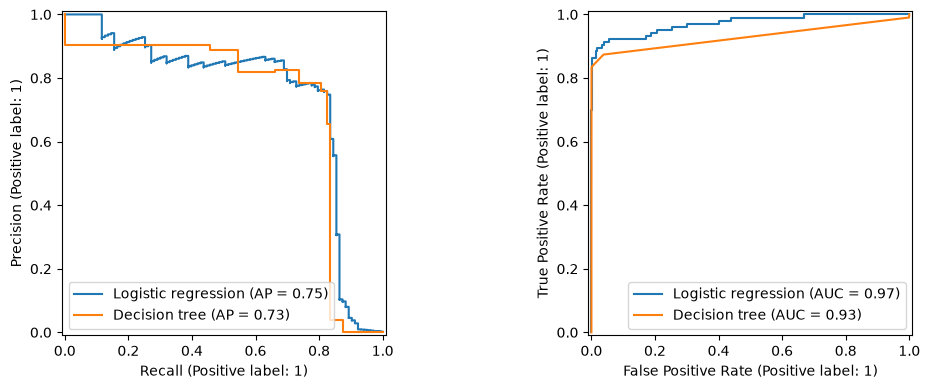

In [17]:
#| label: fig-fraud-model-curves
#| fig-cap: "PR and ROC curves emphasize different aspects of the same predictions."
pipe_tree = make_pipeline(DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=42))
pipe_tree.fit(X_fit, y_fit)
comparison_models = {"Logistic regression": pipe_lr, "Decision tree": pipe_tree}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, model in comparison_models.items():
    PrecisionRecallDisplay.from_estimator(model, X_valid, y_valid, name=name, ax=axes[0])
    RocCurveDisplay.from_estimator(model, X_valid, y_valid, name=name, ax=axes[1])
fig.tight_layout()
plt.show()

### Returning to the search problem

Chapter 8 defined a candidate pipeline by its preprocessing, model family, and hyperparameters. We now need to specify **how candidates will be compared**. Evaluation metrics define the selection objective; thresholds add another decision to the workflow.

First, let us inspect several metrics using cross-validation within the training set. Precision, recall, and F1 here use each estimator's default class predictions. AP and ROC AUC use its scores. The `test_` prefix below refers to held-out cross-validation folds, not our reserved test set.

In [18]:
cv_comparison = {}
for name, model in comparison_models.items():
    result = cross_validate(model, X_fit, y_fit, scoring=scoring, cv=CV)
    cv_comparison[name] = {
        metric: result[f"test_{metric}"].mean() for metric in scoring
    }
pd.DataFrame(cv_comparison).T

,accuracy,precision,recall,f1,average_precision,roc_auc
Logistic regression,0.999162,0.865437,0.609877,0.713506,0.742913,0.961859
Decision tree,0.999183,0.812121,0.688580,0.743993,0.696873,0.916331


#### Selecting a candidate with an explicit objective

For this demonstration, we choose the pipeline with the highest mean cross-validation AP, then select an operating threshold separately. This is a tractable two-stage strategy, not a guarantee of the highest attainable precision at our recall target. A search designed specifically around that target could choose a different model.

We search a small set of logistic-regression and tree configurations. Keeping the search small makes the workflow reproducible without making computation the focus of the chapter. Scaling stays inside the pipeline; it is useful for logistic regression and unnecessary but harmless for this tree.

In [ ]:
search_pipeline = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
# Use a common final-step name so the search can replace the estimator.
search_pipeline.steps[-1] = ("classifier", search_pipeline.steps[-1][1])
param_grid = [
    {"classifier": [LogisticRegression(max_iter=2000)], "classifier__C": [0.1, 1, 10]},
    {"classifier": [DecisionTreeClassifier(min_samples_leaf=20, random_state=42)],
     "classifier__max_depth": [3, 5, 8]},
]
search = GridSearchCV(
    search_pipeline, param_grid, scoring=scoring, refit="average_precision",
    cv=CV, n_jobs=1, error_score="raise",
)
search.fit(X_fit, y_fit)
result_columns = ["params", "mean_test_average_precision", "std_test_average_precision",
                  "mean_test_precision", "mean_test_recall", "mean_test_f1", "mean_test_roc_auc"]
pd.DataFrame(search.cv_results_)[result_columns].sort_values(
    "mean_test_average_precision", ascending=False
)

With multiple metrics, [`refit="average_precision"`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) specifies which one selects the winner. The chosen pipeline is refitted on all of `X_fit`; validation and test data are not included in that refit. A small difference in mean score is not necessarily meaningful, and variation across folds is not a confidence interval.

Changing `scoring` does not change the loss used inside `fit`. Logistic regression still fits using regularized log loss. AP tells the outer search which fitted candidate to select.

#### Selecting the operating threshold

Now we apply that fitted pipeline to the validation set. Among thresholds attaining at least 0.8 validation recall, we choose the one with the highest precision. If several tie, we choose the highest threshold. If a requirement were infeasible, we would report that rather than silently relaxing it. Here predicting everything positive makes a recall-only constraint attainable, though possibly with unacceptable precision.

In [ ]:
selected_model = search.best_estimator_
selected_probability = selected_model.predict_proba(X_valid)[:, list(selected_model.classes_).index(1)]
precision, recall, thresholds = precision_recall_curve(y_valid, selected_probability)
# The last precision/recall pair has no corresponding threshold.
threshold_candidates = pd.DataFrame({
    "threshold": thresholds, "precision": precision[:-1], "recall": recall[:-1],
})
feasible = threshold_candidates.query("recall >= 0.8")
chosen = feasible.sort_values(["precision", "threshold"], ascending=False).iloc[0]
selected_threshold = float(chosen["threshold"])
chosen.to_frame("Selected validation operating point")

This validation score was used to choose a threshold, so it is not an independent estimate of the chosen system's performance. Our earlier plots also used this validation set. Repeatedly adjusting models, objectives, or requirements in response to those plots adds to the optimization bias discussed in Chapter 8.

#### Final evaluation

We now freeze both the fitted pipeline and its threshold. We do not refit on the validation data here: refitting could change the score distribution and invalidate the threshold we just selected. More elaborate workflows can use cross-validation to make efficient use of development data, but must still keep threshold selection separate from final evaluation.

Only now do we evaluate the reserved test set. Report the counts as well as the summary metrics so readers can see the practical scale of the errors.

In [ ]:
test_probability = selected_model.predict_proba(X_test)[:, list(selected_model.classes_).index(1)]
test_prediction = test_probability >= selected_threshold
final_metrics = prediction_metrics(y_test, test_prediction)
final_metrics["AP"] = average_precision_score(y_test, test_probability)
final_metrics["ROC AUC"] = roc_auc_score(y_test, test_probability)
pd.Series(final_metrics, name="Final test evaluation").to_frame()

Test recall need not meet the validation target exactly. The sample is different, and selecting a threshold does not guarantee future performance. If the result is disappointing, report it honestly. Using it to revise the model or threshold turns this test set into development data; the revised system needs a fresh independent evaluation.

::: {.callout-note collapse="true" title="Optional activity: What aggregate metrics hide"}

A classifier can perform well overall while making different mistakes for different groups. We will examine this using the Adult census dataset already used in the lecture material. The task is to predict the dataset's income category. These historical income labels are not measures of merit or creditworthiness.

To keep the activity focused, we use a small set of familiar numeric and categorical features. We keep the recorded `sex` column separately for evaluation. Its two recorded categories do not represent the full range of sex or gender identities. Omitting it from the features does not guarantee fairness: other features can contain related information.

In [ ]:
adult_df = pd.read_csv(DATA_DIR / "adult.csv").replace("?", np.nan)
adult_fit, adult_eval = train_test_split(
    adult_df, test_size=0.3, random_state=42, stratify=adult_df["income"]
)
adult_numeric = ["age", "capital.gain", "capital.loss", "hours.per.week"]
adult_categorical = ["workclass", "education", "occupation", "marital.status"]
adult_features = adult_numeric + adult_categorical
adult_preprocessor = make_column_transformer(
    (make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), adult_numeric),
    (make_pipeline(SimpleImputer(strategy="most_frequent"),
                   OneHotEncoder(handle_unknown="ignore")), adult_categorical),
)
adult_model = make_pipeline(adult_preprocessor, LogisticRegression(max_iter=2000))
adult_y_fit = adult_fit["income"].str.strip().str.rstrip(".").eq(">50K").astype(int)
adult_y_eval = adult_eval["income"].str.strip().str.rstrip(".").eq(">50K").astype(int)
adult_model.fit(adult_fit[adult_features], adult_y_fit)
adult_predictions = pd.Series(adult_model.predict(adult_eval[adult_features]), index=adult_eval.index)
group_results = {}
for group, rows in adult_eval.groupby("sex"):
    metrics = prediction_metrics(adult_y_eval.loc[rows.index], adult_predictions.loc[rows.index])
    metrics["support"] = len(rows)
    metrics["prevalence"] = adult_y_eval.loc[rows.index].mean()
    metrics["FPR"] = metrics["FP"] / (metrics["FP"] + metrics["TN"])
    metrics["positive prediction rate"] = adult_predictions.loc[rows.index].mean()
    group_results[group] = metrics
pd.DataFrame(group_results).T

Use the table to discuss the following:

1. Which differences would you miss by reporting only overall accuracy? Compare recall, FPR, and positive prediction rates, keeping their denominators distinct.
2. Could differences in prevalence help explain differences in precision? What additional evidence would you need before explaining why the groups differ?
3. Suppose someone proposes using the predictions to decide who receives financial opportunities. What assumptions would that add beyond predicting recorded income? Who could be harmed by each kind of mistake?
4. Does excluding `sex` establish fair treatment? Does matching one metric across groups establish it?

These comparisons can identify questions worth investigating; they do not establish causes or settle what fairness requires. Labels, data collection, the proposed use, affected people's perspectives, and uncertainty for small groups all matter. If we use these evaluation results to improve the model, we need new held-out data to assess the revised system.

:::

## Exercises

### Exercise 9.1: Higher accuracy, better detector?

Two classifiers are evaluated on the same 95 negative and 5 positive examples. Model A has TN=90, FP=5, FN=5, TP=0. Model B has TN=80, FP=15, FN=0, TP=5. Compute accuracy, precision, and recall. Which would you choose if missed positives are particularly costly? What else would you want to know?

::: {.callout-tip collapse="true" title="Solution"}
A has accuracy 0.90, precision 0, and recall 0. B has accuracy 0.85, precision 0.25, and recall 1. B catches every positive at the cost of more false alarms. It is a plausible choice when misses are particularly costly, but we still need the consequences and costs of false alarms, operational capacity, and evidence that this evaluation represents future use.
:::

### Exercise 9.2: Lowering the threshold

A model has TP=6, FP=4, FN=2, TN=88. Lowering the threshold flags three additional transactions: two are fraud and one is legitimate. Find the new precision and recall. Does this contradict the usual precision–recall trade-off?

::: {.callout-tip collapse="true" title="Solution"}
The new counts are TP=8, FP=5, FN=0, TN=87. Precision increases from 0.60 to $8/13\approx0.615$, and recall increases from 0.75 to 1. Precision need not fall when the threshold falls; it depends on the newly flagged examples. Recall cannot decrease on the same fixed examples.
:::

### Exercise 9.3: Choosing a model for review

A review team needs at least 0.8 recall. Model A has AP=0.90 and precision 0.50 at its best validation threshold meeting that requirement. Model B has AP=0.86 and precision 0.70 at its best qualifying threshold. Which would you select under the stated requirement? Why can the AP ranking disagree?

::: {.callout-tip collapse="true" title="Solution"}
B better meets the stated goal of high precision subject to the recall requirement. AP summarizes a range of recall values, so A can have better overall AP while being worse in the operating region. These are validation-based choices; an untouched evaluation is still needed, and differences may be uncertain with few positives.
:::

### Exercise 9.4: Find the evaluation leak

A student selects a pipeline using cross-validation, tries 100 thresholds on the test set, and reports the highest test F1. They say the test set was never passed to `fit`, so the evaluation is independent. Explain the error and propose a repair.

::: {.callout-tip collapse="true" title="Solution"}
Choosing a threshold uses the test labels to select the decision rule, even without calling `fit`. Threshold selection belongs in development data, such as a separate validation set. Freeze the fitted pipeline and threshold before independent evaluation. Since these test results have already guided selection, the revised system needs fresh held-out evaluation data.
:::

## Summary

- Accuracy counts all correct decisions equally; confusion matrices reveal which mistakes occur.
- Precision measures the reliability of positive predictions, recall measures how many positives are caught, and F1 summarizes both at a particular threshold.
- Threshold changes alter decisions without refitting. Their consequences must be evaluated in the application context.
- PR/AP and ROC/AUC describe rankings across thresholds; a summary can hide the operating region that matters.
- Choose the evaluation objective deliberately, compare candidates using development data, and protect the test set from both model and threshold selection.
- Aggregate metrics can hide group differences, and no single metric establishes fair treatment.